### IRIS Flowers Classification Using Machine Learning

##### Introduction on Classification

在这篇关于鸢尾花分类的文章中，我们将使用逻辑回归机器学习算法。首先，我们将了解逻辑回归，然后我们将理解该算法在鸢尾花数据集上的工作原理。我们都知道鸢尾花数据集，它包含不同花卉品种的特征。该数据集中的自变量特征是萼片长度、萼片宽度、花瓣长度和花瓣宽度。所有这些长度都以厘米为单位。而因变量特征，也就是模型的输出，是物种。它包含具有这些测量值的特定花朵所属的物种名称。

在创建机器学习模型之前，让我们先了解逻辑回归。

#### Decision Tree

#### Working with Dataset

在创建模型并进行训练之前，我们必须对数据集进行预处理。预处理意味着在将数据集用于任何机器学习算法之前，将其转换为可理解的格式。它包括数据转换、数据规约、数据清洗以及更多其他处理。

让我们使用逻辑回归构建一个机器学习模型。为此，我们将采用鸢尾花数据集。

首先，我们加载一些重要的Python Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.simplefilter("ignore")

`matplotlib和seaborn`用于可视化，而`warnings`则用于忽略我们遇到的所有警告。

从本地桌面导入数据集。使用`pandas`来完成这个任务。在`read_csv`方法中输入数据集文件的路径。它将导入鸢尾花数据集。

In [2]:
# Import test and train dataset
test = pd.read_csv('results/nkt_t_test_df.csv', index_col=0)
test.head()

,HES4,ISG15,TNFRSF18,TNFRSF4,MMP23B,NADK,MEGF6,TNFRSF25,TNFRSF9,ERRFI1,...,LDOC1,AFF2,ZNF185,PNMA3,PDZD4,TKTL1,PLXNA3,MPP1,CLIC2,coarse_anno
AAACAAGCACATTGTCACTTTAGG-1,0.0,0.0,0.000000,0.0,0.0,0.000000,0.825543,1.813600,0.0,0.0,...,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,T cells
AAACAAGCACCATACTACTTTAGG-1,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.00000,1.494708,0.0,1.003942,0.0,0.0,T cells
AAACAAGCATTTGTTGACTTTAGG-1,0.0,0.0,1.256215,0.0,0.0,0.608334,0.608334,0.983850,0.0,0.0,...,0.983850,0.0,0.0,0.98385,0.000000,0.0,0.000000,0.0,0.0,T cells
AAACCAATCAAACCGGACTTTAGG-1,0.0,0.0,0.663697,0.0,0.0,0.000000,0.663697,0.663697,0.0,0.0,...,0.663697,0.0,0.0,0.00000,0.663697,0.0,0.000000,0.0,0.0,T cells
AAACCAGGTGATTACCACTTTAGG-1,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.328549,0.0,0.0,...,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,T cells


In [3]:
train = pd.read_csv('results/nkt_t_train_df.csv', index_col=0)
train.head()

,HES4,ISG15,TNFRSF18,TNFRSF4,MMP23B,NADK,MEGF6,TNFRSF25,TNFRSF9,ERRFI1,...,LDOC1,AFF2,ZNF185,PNMA3,PDZD4,TKTL1,PLXNA3,MPP1,CLIC2,coarse_anno
GTCGGTTTCGAACCGAACAGACCT-1,0.0,0.00000,0.0,0.00000,0.0,0.00000,0.000000,0.000000,0.0,0.0,...,0.0,0.870465,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,T cells
GTGGCTAAGCTATCCAATGTTGAC-1,0.0,0.00000,0.0,0.00000,0.0,0.00000,1.358178,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,1.913711,0.000000,0.000000,T cells
GTAAAGCTCGTTCGTAAAGTAGAG-1,0.0,0.00000,0.0,1.35519,0.0,1.35519,1.355190,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,T cells
AGGTTCGAGGCGCATAACTACTCA-1,0.0,0.00000,0.0,0.00000,0.0,0.00000,0.000000,1.370298,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.903514,0.903514,T cells
AAGAATCGTAGCGCGAATCATGTG-1,0.0,0.74009,0.0,0.00000,0.0,0.00000,1.455908,0.740090,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,T cells


查看数据框的信息，其中包含非空变量的计数以及列的数据类型和列名等详细信息。它还将显示内存使用情况。

In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55200 entries, AAACAAGCACATTGTCACTTTAGG-1 to TTTGTGAGTAGTTGTCATTCGGTT-1
Columns: 2100 entries, HES4 to coarse_anno
dtypes: float64(2099), object(1)
memory usage: 884.8+ MB


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, GTCGGTTTCGAACCGAACAGACCT-1 to GGATTATCAGCTTTCGAACGGGAA-1
Columns: 2100 entries, HES4 to coarse_anno
dtypes: float64(2099), object(1)
memory usage: 32.1+ MB


如果有任何缺失值，那么在使用数据集之前对它们进行修改。对于修改，你可以使用fillna()方法。它将填充空值。

In [6]:
# checking for null values
train.isnull().sum()

HES4           0
ISG15          0
TNFRSF18       0
TNFRSF4        0
MMP23B         0
              ..
TKTL1          0
PLXNA3         0
MPP1           0
CLIC2          0
coarse_anno    0
Length: 2100, dtype: int64

In [7]:
test.isnull().sum()

HES4           0
ISG15          0
TNFRSF18       0
TNFRSF4        0
MMP23B         0
              ..
TKTL1          0
PLXNA3         0
MPP1           0
CLIC2          0
coarse_anno    0
Length: 2100, dtype: int64

我们可以看到所有值都是0。这意味着整个数据框中没有空值。

要查看数据框中的列名，请使用columns

In [8]:
train.columns

Index(['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MMP23B', 'NADK', 'MEGF6',
       'TNFRSF25', 'TNFRSF9', 'ERRFI1',
       ...
       'LDOC1', 'AFF2', 'ZNF185', 'PNMA3', 'PDZD4', 'TKTL1', 'PLXNA3', 'MPP1',
       'CLIC2', 'coarse_anno'],
      dtype='object', length=2100)

In [9]:
markers = pd.read_csv('results/nkt_t_marker.csv', index_col=0)
markers

,cell_type,marker_gene
0,NKT,NCAM1
1,NKT,DAB2IP
2,NKT,SLC4A10
3,NKT,ME1
4,NKT,CCR1
5,NKT,LTK
6,NKT,IL23R
7,NKT,BLK
8,NKT,KLRF1
9,NKT,RNF165


#### 在训练集中，只保留coarse_marker_genes

In [10]:
# 从markers DataFrame中提取所有标志基因  
marker_genes = markers['marker_gene'].tolist()
marker_genes[1:10]

['DAB2IP', 'SLC4A10', 'ME1', 'CCR1', 'LTK', 'IL23R', 'BLK', 'KLRF1', 'RNF165']

In [11]:
# 添加coarse_anno  
selected_columns = [col for col in train.columns if col in marker_genes]  
selected_columns.append('coarse_anno')

In [12]:
# 创建新的DataFrame，只保留标志基因列和coarse_anno列  
train_data = train[selected_columns]
train_data.head()

,TCEA3,MAN1C1,IL23R,SELL,TRABD2A,MAL,IL18RAP,SLC4A10,CCDC141,CCR1,...,NCAM1,KLRF1,TBC1D4,ACTN1,LTK,CCR7,NOG,RNF165,IL4I1,coarse_anno
GTCGGTTTCGAACCGAACAGACCT-1,0.000000,2.071927,0.0,2.789215,2.071927,1.328677,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.870465,2.071927,0.0,1.879784,1.328677,0.0,0.0,T cells
GTGGCTAAGCTATCCAATGTTGAC-1,0.000000,1.358178,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,T cells
GTAAAGCTCGTTCGTAAAGTAGAG-1,0.000000,1.670768,0.0,3.720499,1.355190,0.891485,0.0,0.0,0.891485,0.0,...,0.0,0.0,0.891485,1.910283,0.0,2.404351,1.355190,0.0,0.0,T cells
AGGTTCGAGGCGCATAACTACTCA-1,0.903514,0.903514,0.0,2.545224,1.927607,1.927607,0.0,0.0,0.903514,0.0,...,0.0,0.0,0.903514,1.927607,0.0,2.422839,0.903514,0.0,0.0,T cells
AAGAATCGTAGCGCGAATCATGTG-1,0.740090,2.025084,0.0,2.385558,1.868817,0.740090,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.740090,1.868817,0.0,2.279214,0.740090,0.0,0.0,T cells


In [13]:
# 查看结果  
print(f"原始训练数据形状: {train.shape}")  
print(f"标志基因数量: {len(marker_genes)}")  
print(f"最终选择的列数: {len(selected_columns)}")  
print(f"新训练数据形状: {train_data.shape}")  
print("\n所选基因列:")  
print(train_data.columns.tolist())

原始训练数据形状: (2000, 2100)
标志基因数量: 30
最终选择的列数: 31
新训练数据形状: (2000, 31)

所选基因列:
['TCEA3', 'MAN1C1', 'IL23R', 'SELL', 'TRABD2A', 'MAL', 'IL18RAP', 'SLC4A10', 'CCDC141', 'CCR1', 'FHIT', 'P2RY14', 'LEF1', 'SERINC5', 'ME1', 'BLK', 'EPHX2', 'CEBPD', 'TLE1', 'SUSD3', 'DAB2IP', 'NCAM1', 'KLRF1', 'TBC1D4', 'ACTN1', 'LTK', 'CCR7', 'NOG', 'RNF165', 'IL4I1', 'coarse_anno']


如果我们查看数据框，我们可以看到有两列具有相同的id编号。要删除不需要的ID列，请使用drop方法。

#### 在测试集中，只保留coarse_marker_genes

In [14]:
# 添加coarse_anno  
selected_columns = [col for col in test.columns if col in marker_genes]  
selected_columns.append('coarse_anno')

In [15]:
# 创建新的DataFrame，只保留标志基因列和coarse_anno列  
test_data = test[selected_columns]
test_data.head()

,TCEA3,MAN1C1,IL23R,SELL,TRABD2A,MAL,IL18RAP,SLC4A10,CCDC141,CCR1,...,NCAM1,KLRF1,TBC1D4,ACTN1,LTK,CCR7,NOG,RNF165,IL4I1,coarse_anno
AAACAAGCACATTGTCACTTTAGG-1,0.0,0.825543,0.0,2.529568,2.421698,1.578847,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.00000,1.271512,0.000000,0.825543,0.000000,0.00000,0.0,T cells
AAACAAGCACCATACTACTTTAGG-1,0.0,0.000000,0.0,0.000000,0.000000,0.000000,1.494708,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,T cells
AAACAAGCATTTGTTGACTTTAGG-1,0.0,0.608334,0.0,0.608334,1.646124,2.543423,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.00000,1.795785,0.000000,0.000000,0.000000,0.98385,0.0,T cells
AAACCAATCAAACCGGACTTTAGG-1,0.0,0.000000,0.0,0.000000,0.000000,1.341788,0.000000,0.0,0.0,0.0,...,0.0,0.0,1.05915,0.000000,1.341788,0.000000,0.000000,0.00000,0.0,T cells
AAACCAGGTGATTACCACTTTAGG-1,0.0,0.870365,0.0,2.601951,2.493391,1.641584,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.00000,1.328549,0.000000,1.641584,0.870365,0.00000,0.0,T cells


In [16]:
# 查看结果  
print(f"原始测试数据形状: {test.shape}")  
print(f"标志基因数量: {len(marker_genes)}")  
print(f"最终选择的列数: {len(selected_columns)}")  
print(f"新测试数据形状: {test_data.shape}")  
print("\n所选基因列:")  
print(test_data.columns.tolist())

原始测试数据形状: (55200, 2100)
标志基因数量: 30
最终选择的列数: 31
新测试数据形状: (55200, 31)

所选基因列:
['TCEA3', 'MAN1C1', 'IL23R', 'SELL', 'TRABD2A', 'MAL', 'IL18RAP', 'SLC4A10', 'CCDC141', 'CCR1', 'FHIT', 'P2RY14', 'LEF1', 'SERINC5', 'ME1', 'BLK', 'EPHX2', 'CEBPD', 'TLE1', 'SUSD3', 'DAB2IP', 'NCAM1', 'KLRF1', 'TBC1D4', 'ACTN1', 'LTK', 'CCR7', 'NOG', 'RNF165', 'IL4I1', 'coarse_anno']


In [17]:
train['coarse_anno'].value_counts()

coarse_anno
T cells    1000
NKT        1000
Name: count, dtype: int64

定义`x`和`y`。`x`包含所有输入变量，如自变量特征，而`y`应包含因变量，它依赖于自变量，即输出。

In [18]:
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  
import matplotlib.pyplot as plt  
import seaborn as sns

In [19]:
# 分离特征和目标变量  
# 前35列是特征，最后一列是目标变量  
X_train = train_data.iloc[:, :-1]  # 所有行，除了最后一列  
y_train = train_data.iloc[:, -1]   # 所有行，只取最后一列  

X_test = test_data.iloc[:, :-1]    # 所有行，除了最后一列  
y_test = test_data.iloc[:, -1]     # 所有行，只取最后一列 

In [20]:
# 查看目标变量的类别分布  
print("训练集目标变量分布:")  
print(y_train.value_counts())

训练集目标变量分布:
coarse_anno
T cells    1000
NKT        1000
Name: count, dtype: int64


In [21]:
# 随机森林  
from sklearn.ensemble import RandomForestClassifier  

In [22]:
rf_model = RandomForestClassifier(  
    n_estimators=100,  
    max_depth=None,  
    min_samples_split=2,  
    random_state=42,  
    class_weight='balanced'  
)

In [23]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [24]:
y_pred_rf = rf_model.predict(X_test)

In [25]:
# 评估模型性能  
accuracy = accuracy_score(y_test, y_pred_rf)  
print(f"\n模型准确率: {accuracy:.4f}")


模型准确率: 0.9120


In [26]:
# 打印详细的分类报告  
print("\n分类报告:")  
print(classification_report(y_test, y_pred_rf))


分类报告:
              precision    recall  f1-score   support

         NKT       0.18      0.85      0.29      1189
     T cells       1.00      0.91      0.95     54011

    accuracy                           0.91     55200
   macro avg       0.59      0.88      0.62     55200
weighted avg       0.98      0.91      0.94     55200



In [27]:
# 创建结果DataFrame  
results_df = pd.DataFrame({  
    'cell_id': X_test.index,  # 使用测试数据的索引作为cell_id  
    'cell_type': y_pred_rf       # 使用模型预测的细胞类型  
}) 

In [28]:
results_df.head(10)

,cell_id,cell_type
0,AAACAAGCACATTGTCACTTTAGG-1,T cells
1,AAACAAGCACCATACTACTTTAGG-1,T cells
2,AAACAAGCATTTGTTGACTTTAGG-1,T cells
3,AAACCAATCAAACCGGACTTTAGG-1,T cells
4,AAACCAGGTGATTACCACTTTAGG-1,T cells
5,AAACCAGGTGGTTATCACTTTAGG-1,T cells
6,AAACCAGGTTAAGGCAACTTTAGG-1,T cells
7,AAACGGGCAACCCTATACTTTAGG-1,T cells
8,AAACGGGCAATACTGGACTTTAGG-1,T cells
9,AAACGGGCAATCGTTCACTTTAGG-1,T cells


#### 集成方法

In [29]:
# 投票分类器  
from sklearn.ensemble import VotingClassifier  
from sklearn.svm import SVC 

In [30]:
# 创建不同算法的模型  
estimators = [  
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),  
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),  
    ('svc', SVC(probability=True, random_state=42))  
]

In [31]:
# 创建投票分类器  
voting_clf = VotingClassifier(estimators=estimators, voting='soft')  
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [32]:
y_pred_voting = voting_clf.predict(X_test)  
print(f"投票分类器准确率: {accuracy_score(y_test, y_pred_voting):.4f}")  

投票分类器准确率: 0.9106


In [33]:
y_test

AAACAAGCACATTGTCACTTTAGG-1    T cells
AAACAAGCACCATACTACTTTAGG-1    T cells
AAACAAGCATTTGTTGACTTTAGG-1    T cells
AAACCAATCAAACCGGACTTTAGG-1    T cells
AAACCAGGTGATTACCACTTTAGG-1    T cells
                               ...   
TTTGCTCTCACCAGCTATTCGGTT-1        NKT
TTTGCTCTCGATGAACATTCGGTT-1    T cells
TTTGCTGAGGTCAAACATTCGGTT-1    T cells
TTTGGCGGTACACCCAATTCGGTT-1    T cells
TTTGTGAGTAGTTGTCATTCGGTT-1    T cells
Name: coarse_anno, Length: 55200, dtype: object

In [34]:
# 假设y_test是真实标签，y_pred_voting是投票分类器的预测结果  
# 将标签转换为字符串类型  
y_true_str = [str(label) for label in y_test]  
y_pred_str = [str(label) for label in y_pred_voting] 

In [35]:
# 计算整体准确率  
accuracy = accuracy_score(y_true_str, y_pred_str)  
print(f"Voting Classifier Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")  

Voting Classifier Accuracy: 0.9106 (91.06%)


In [36]:
# 生成详细的分类报告  
try:  
    report = classification_report(  
        y_true_str, y_pred_str,   
        output_dict=True,   
        zero_division=0  
    )  
    report_df = pd.DataFrame(report).transpose()  
    print("\nClassification Report:")  
    print(report_df.round(3))  
except Exception as e:  
    print(f"Error generating classification report: {e}")


Classification Report:
              precision  recall  f1-score    support
NKT               0.174   0.841     0.288   1189.000
T cells           0.996   0.912     0.952  54011.000
accuracy          0.911   0.911     0.911      0.911
macro avg         0.585   0.877     0.620  55200.000
weighted avg      0.978   0.911     0.938  55200.000


In [37]:
# 获取所有唯一的类别标签  
unique_true_labels = np.unique(y_true_str)  
unique_pred_labels = np.unique(y_pred_str)  
all_classes = sorted(list(set(list(unique_true_labels) + list(unique_pred_labels))))  

# 计算混淆矩阵  
cm = confusion_matrix(y_true_str, y_pred_str, labels=all_classes)

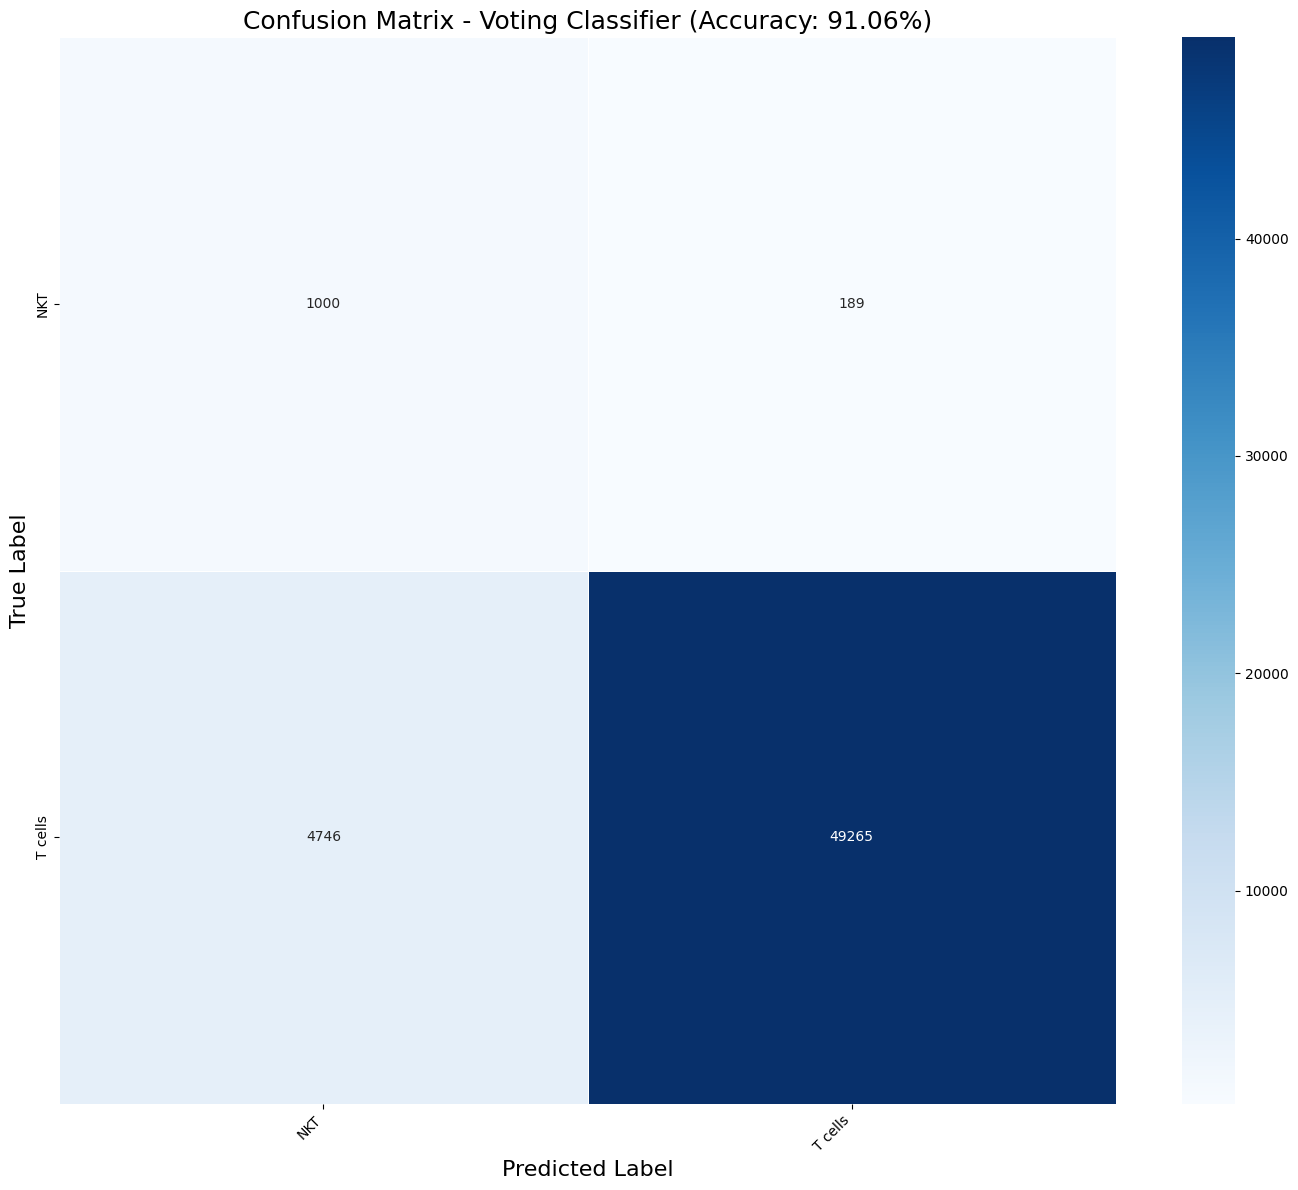

In [38]:
# 创建DataFrame以便于使用seaborn绘图  
cm_df = pd.DataFrame(cm, index=all_classes, columns=all_classes)  

# 设置图形大小  
plt.figure(figsize=(14, 12))  

# 使用seaborn绘制热图  
heatmap = sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", linewidths=.5)  

# 添加标题和标签  
plt.title(f'Confusion Matrix - Voting Classifier (Accuracy: {accuracy*100:.2f}%)', fontsize=18)  
plt.ylabel('True Label', fontsize=16)  
plt.xlabel('Predicted Label', fontsize=16)  
plt.xticks(fontsize=10, rotation=45, ha='right')  
plt.yticks(fontsize=10)  

# 调整布局以确保标签完全可见  
plt.tight_layout()  

# 显示图形  
plt.show()

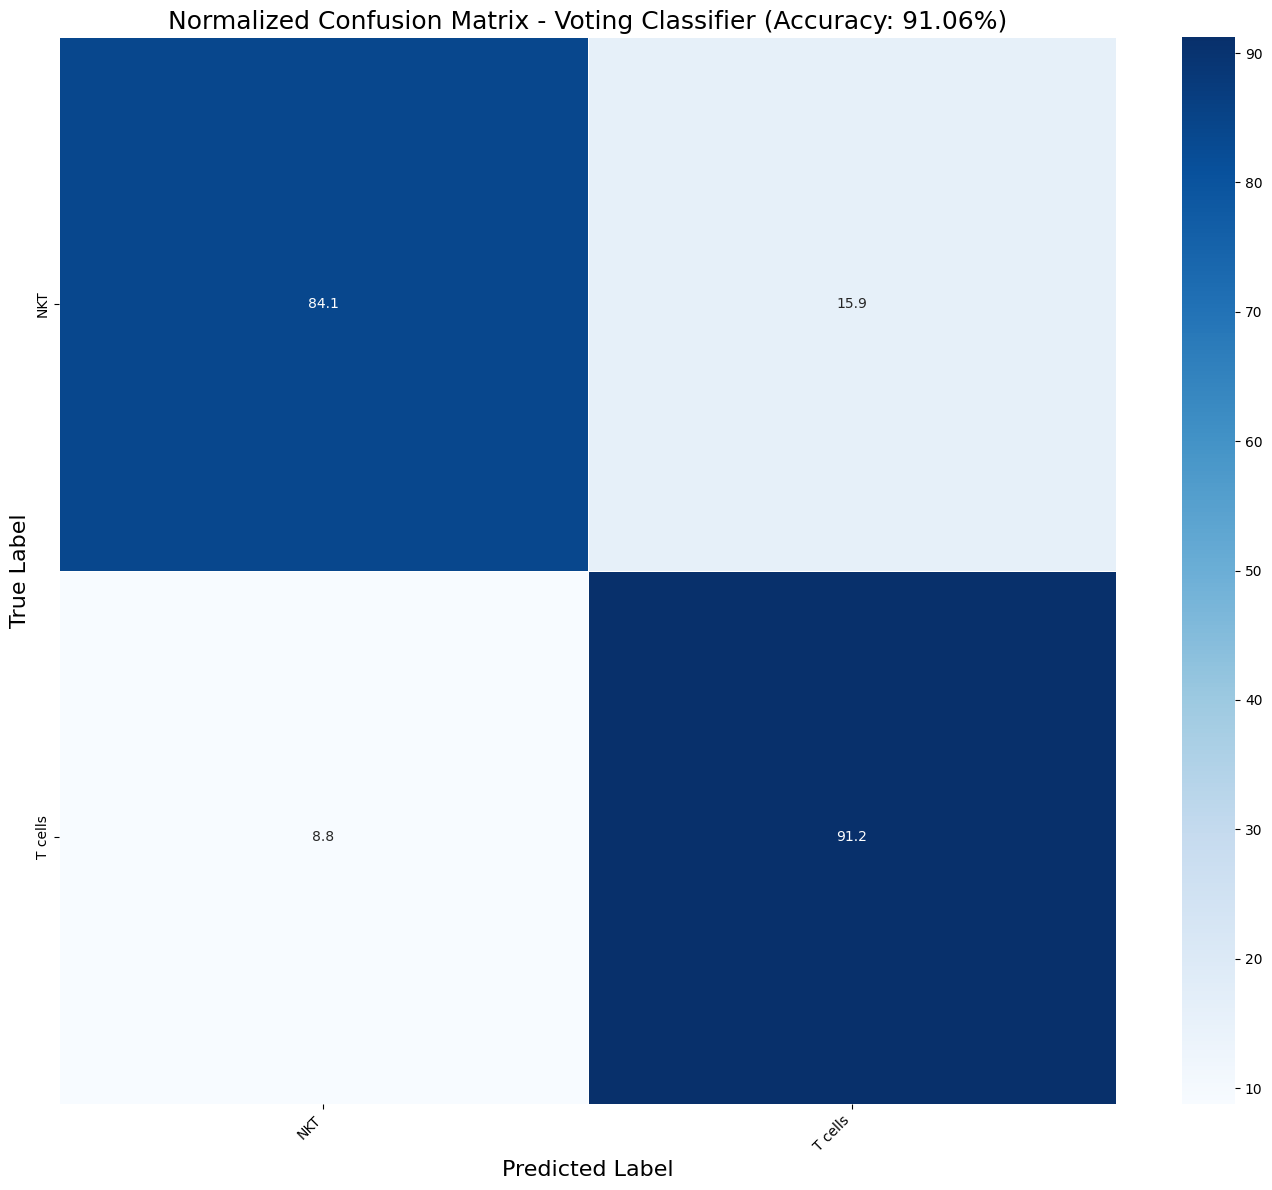

In [39]:
# 计算并绘制百分比混淆矩阵（按行归一化）  
row_sums = cm.sum(axis=1)  
# 避免除以零  
row_sums_safe = np.maximum(row_sums, 1)  # 将零替换为1以避免除以零  
cm_percent = (cm.astype('float') / row_sums_safe[:, np.newaxis]) * 100  
cm_percent_df = pd.DataFrame(cm_percent, index=all_classes, columns=all_classes)  

plt.figure(figsize=(14, 12))  
sns.heatmap(cm_percent_df, annot=True, fmt='.1f', cmap="Blues", linewidths=.5)  
plt.title(f'Normalized Confusion Matrix - Voting Classifier (Accuracy: {accuracy*100:.2f}%)', fontsize=18)  
plt.ylabel('True Label', fontsize=16)  
plt.xlabel('Predicted Label', fontsize=16)  
plt.xticks(fontsize=10, rotation=45, ha='right')  
plt.yticks(fontsize=10)  
plt.tight_layout()  
plt.show()


Accuracy by Class:
NKT: 0.8410 (84.10%) - count: 1189
T cells: 0.9121 (91.21%) - count: 54011


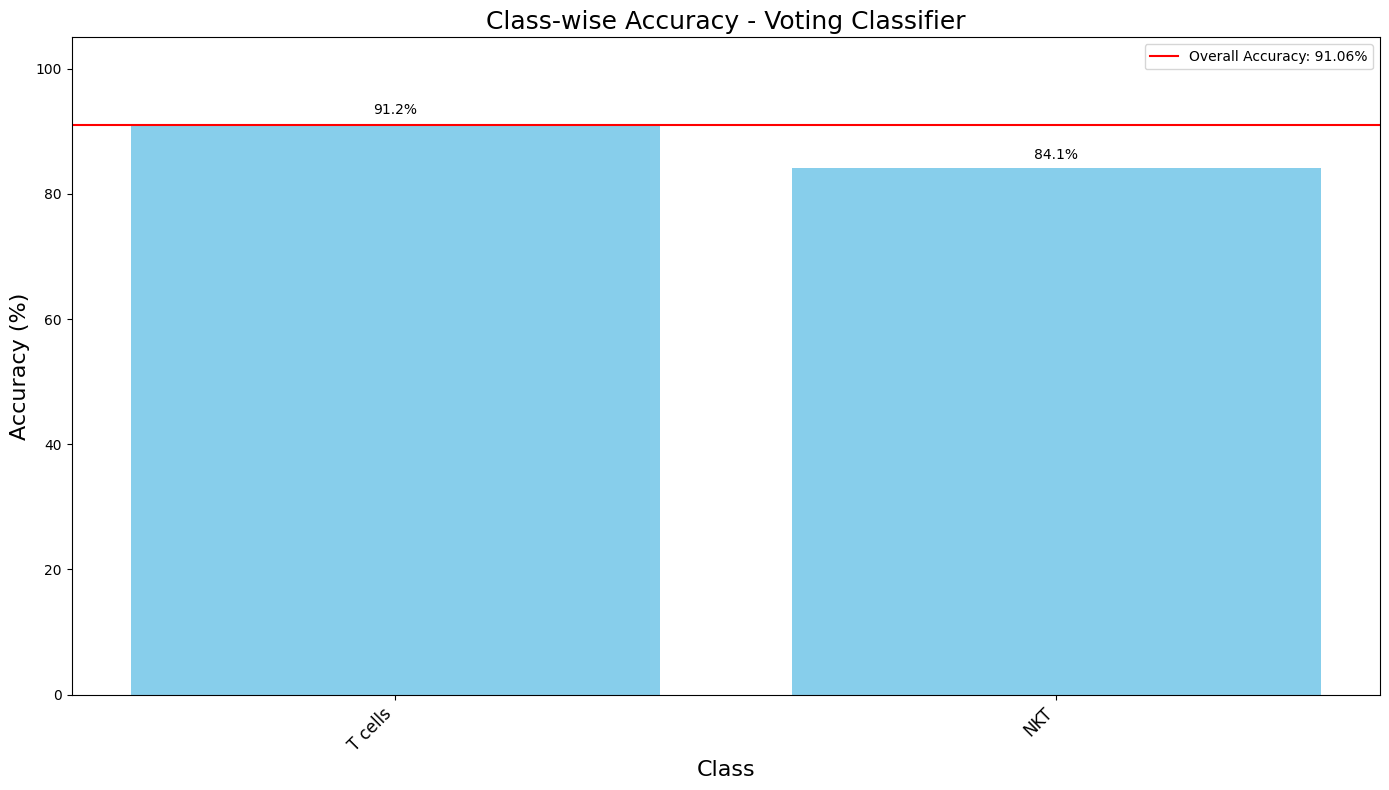

In [40]:
# 计算每个类别的准确率（对角线元素/行总和）  
class_accuracies = {}  
class_counts = {}  
for i, class_name in enumerate(all_classes):  
    total_samples = row_sums[i]  
    correct_predictions = cm[i, i]  
    class_counts[class_name] = total_samples  
    
    if total_samples > 0:  # 避免除以零  
        class_acc = correct_predictions / total_samples  
    else:  
        class_acc = np.nan  # 使用NaN表示没有样本的类别  
    
    class_accuracies[class_name] = class_acc  

# 显示每个类别的准确率和样本数  
print("\nAccuracy by Class:")  
for class_name, acc in class_accuracies.items():  
    count = class_counts[class_name]  
    if np.isnan(acc):  
        print(f"{class_name}: No samples (count: {count})")  
    else:  
        print(f"{class_name}: {acc:.4f} ({acc*100:.2f}%) - count: {count}")  

# 创建并显示每个类别准确率的条形图（仅包含有样本的类别）  
valid_classes = [cls for cls in all_classes if class_counts[cls] > 0]  
valid_accs = [class_accuracies[cls] for cls in valid_classes]  
valid_counts = [class_counts[cls] for cls in valid_classes]  

# 创建排序索引（根据准确率从高到低）  
if valid_classes:  
    sorted_indices = np.argsort(valid_accs)[::-1]  
    sorted_classes = [valid_classes[i] for i in sorted_indices]  
    sorted_accs = [valid_accs[i] for i in sorted_indices]  
    sorted_counts = [valid_counts[i] for i in sorted_indices]  

    plt.figure(figsize=(14, 8))  
    bars = plt.bar(sorted_classes, [acc*100 for acc in sorted_accs], color='skyblue')  
    plt.axhline(y=accuracy*100, color='r', linestyle='-', label=f'Overall Accuracy: {accuracy*100:.2f}%')  

    plt.title('Class-wise Accuracy - Voting Classifier', fontsize=18)  
    plt.xlabel('Class', fontsize=16)  
    plt.ylabel('Accuracy (%)', fontsize=16)  
    plt.xticks(rotation=45, ha='right', fontsize=12)  
    plt.ylim(0, 105)  # 设置y轴范围从0到105%  
    
    # 在条形顶部添加准确率标签  
    for bar in bars:  
        height = bar.get_height()  
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,  
                f'{height:.1f}%', ha='center', va='bottom', rotation=0)  

    plt.legend()  
    plt.tight_layout()  
    plt.show()


Accuracy by Class:
NKT: 0.8410 (84.10%)
T cells: 0.9121 (91.21%)


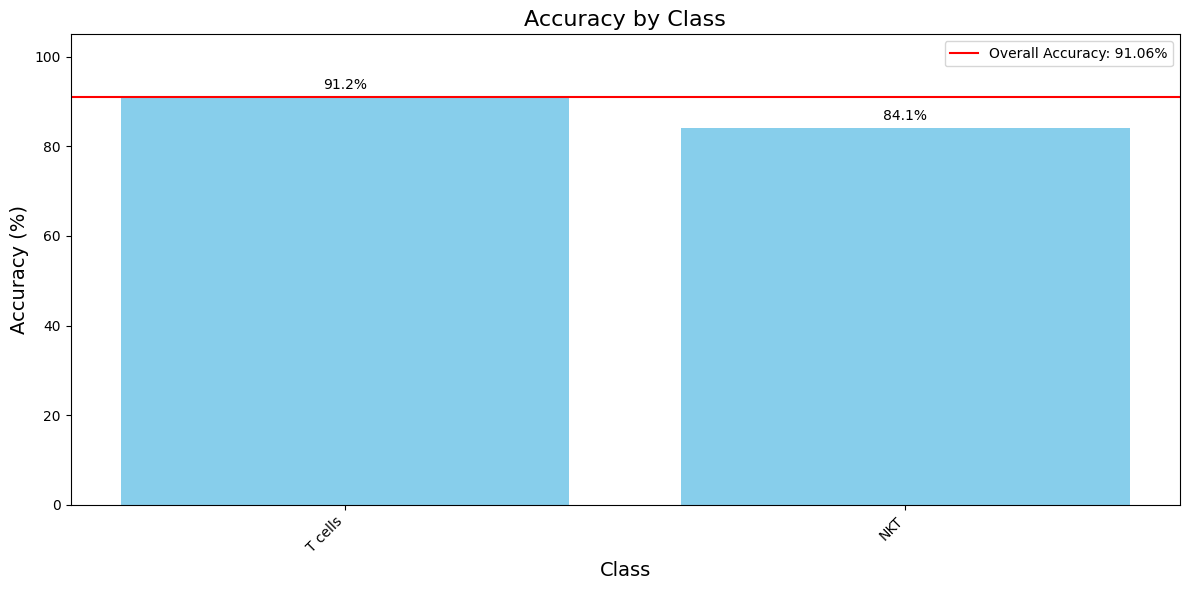

In [41]:
# 计算每个类别的准确率（对角线元素/行总和）  
class_accuracies = {}  
for i, class_name in enumerate(all_classes):  
    if row_sums[i] > 0:  # 避免除以零  
        class_acc = cm[i, i] / row_sums[i]  
        class_accuracies[class_name] = class_acc  

# 显示每个类别的准确率  
print("\nAccuracy by Class:")  
for class_name, acc in class_accuracies.items():  
    print(f"{class_name}: {acc:.4f} ({acc*100:.2f}%)")  

# 可选：创建并显示每个类别准确率的条形图  
plt.figure(figsize=(12, 6))  
classes = list(class_accuracies.keys())  
accs = [class_accuracies[cls] for cls in classes]  

# 排序类别和准确率（从高到低）  
sorted_indices = np.argsort(accs)[::-1]  
sorted_classes = [classes[i] for i in sorted_indices]  
sorted_accs = [accs[i] for i in sorted_indices]  

bars = plt.bar(sorted_classes, [acc*100 for acc in sorted_accs], color='skyblue')  
plt.axhline(y=accuracy*100, color='r', linestyle='-', label=f'Overall Accuracy: {accuracy*100:.2f}%')  

plt.title('Accuracy by Class', fontsize=16)  
plt.xlabel('Class', fontsize=14)  
plt.ylabel('Accuracy (%)', fontsize=14)  
plt.xticks(rotation=45, ha='right')  
plt.ylim(0, 105)  # 设置y轴范围从0到105%  

# 在条形顶部添加准确率标签  
for bar in bars:  
    height = bar.get_height()  
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,  
             f'{height:.1f}%', ha='center', va='bottom', rotation=0)  

plt.legend()  
plt.tight_layout()  
plt.show()  

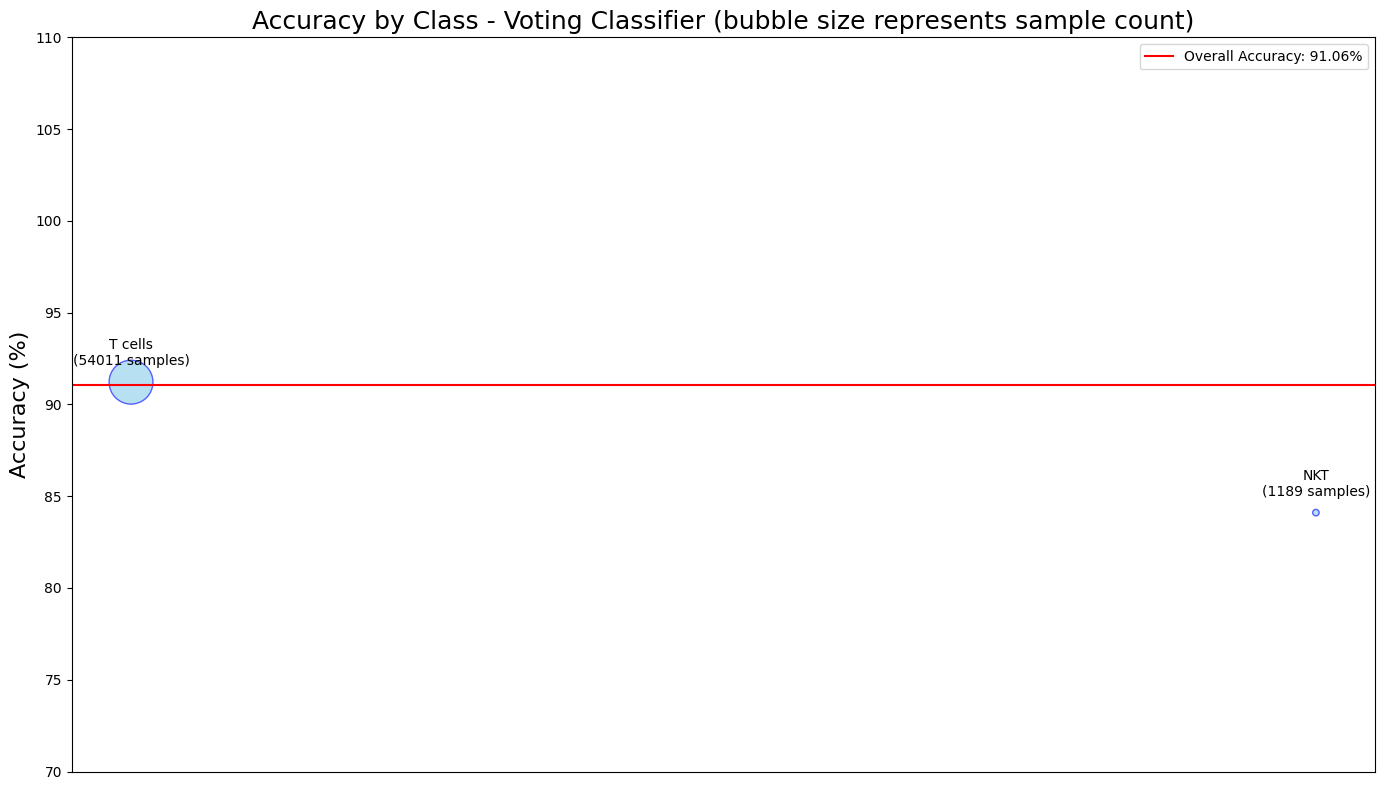

In [42]:
    # 另一种可视化：气泡图 - 同时显示准确率和样本数  
    plt.figure(figsize=(14, 8))  
    
    # 创建气泡图，大小表示样本数  
    sizes = [count/max(sorted_counts)*1000 for count in sorted_counts]  # 归一化大小  
    
    plt.scatter(range(len(sorted_classes)), [acc*100 for acc in sorted_accs],   
               s=sizes, alpha=0.6, c='skyblue', edgecolors='blue')  
    
    plt.axhline(y=accuracy*100, color='r', linestyle='-', label=f'Overall Accuracy: {accuracy*100:.2f}%')  
    
    # 添加标签  
    for i, cls in enumerate(sorted_classes):  
        plt.annotate(f"{cls}\n({sorted_counts[i]} samples)",   
                    (i, sorted_accs[i]*100),  
                    xytext=(0, 10),   
                    textcoords='offset points',  
                    ha='center', va='bottom')  
    
    plt.xticks([])  # 隐藏x轴刻度  
    plt.title('Accuracy by Class - Voting Classifier (bubble size represents sample count)', fontsize=18)  
    plt.ylabel('Accuracy (%)', fontsize=16)  
    plt.ylim(70, 110)  
    plt.legend()  
    plt.tight_layout()  
    plt.show()